In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import platform

# 운영체제별 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac
    plt.rc('font', family='AppleGothic')
else: # Linux (Colab 등)
    plt.rc('font', family='NanumGothic')

# 마이너스 부호 깨짐 해결
plt.rcParams['axes.unicode_minus'] = False    

In [46]:
df = pd.read_csv('data/real_estate_clean_v2.csv', encoding='cp949')
df

/var/folders/s9/dc7mvn1n1nl45gw342h0m_kr0000gn/T/ipykernel_24235/1714618046.py:1: DtypeWarning: Columns (12,15) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/real_estate_clean_v2.csv', encoding='cp949')


,Unnamed: 0.1,Unnamed: 0,CGG_CD,CGG_NM,STDG_CD,STDG_NM,BLDG_NM,CTRT_DAY,THING_AMT,ARCH_AREA,...,RGHT_SE,ARCH_YR,BLDG_USG,DCLR_SE,CTRT_YEAR,QUARTER,QUARTER_INT,CTRT_BLDG_AGE,AMT_PER_AREA,AMT_PER_PYEONG
0,0,14,11530,구로구,10800,오류동,NaN,2018-12-31,73000,197.40,...,NaN,1990,단독다가구,NaN,2018,2018Q4,12,28,369.807497,1222.509625
1,1,16,11215,광진구,10100,중곡동,NaN,2018-12-31,102000,89.09,...,NaN,1973,단독다가구,NaN,2018,2018Q4,12,45,1144.909642,3784.842294
2,2,43,11560,영등포구,10900,영등포동8가,NaN,2018-12-29,88700,36.36,...,NaN,1945,단독다가구,NaN,2018,2018Q4,12,73,2439.493949,8064.479098
3,3,87,11230,동대문구,10900,휘경동,NaN,2018-12-28,95000,140.22,...,NaN,1991,단독다가구,NaN,2018,2018Q4,12,27,677.506775,2239.701897
4,4,92,11620,관악구,10200,신림동,NaN,2018-12-27,56500,179.46,...,NaN,1988,단독다가구,NaN,2018,2018Q4,12,30,314.833389,1040.776218
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
777302,777302,833566,11230,동대문구,11000,이문동,민족통일MJ캠퍼스외대4차,2023-12-04,21000,23.23,...,NaN,2023,오피스텔,중개거래,2023,2023Q4,12,0,904.003444,2988.454585
777303,777303,833567,11230,동대문구,11000,이문동,민족통일MJ캠퍼스외대4차,2023-12-04,21000,23.23,...,NaN,2023,오피스텔,중개거래,2023,2023Q4,12,0,904.003444,2988.454585
777304,777304,833568,11230,동대문구,11000,이문동,민족통일MJ캠퍼스외대4차,2023-12-04,21000,23.23,...,NaN,2023,오피스텔,중개거래,2023,2023Q4,12,0,904.003444,2988.454585
777305,777305,833569,11650,서초구,10800,서초동,벨라채 오피스텔,2023-12-04,24000,36.64,...,NaN,2003,오피스텔,중개거래,2023,2023Q4,12,20,655.021834,2165.371179


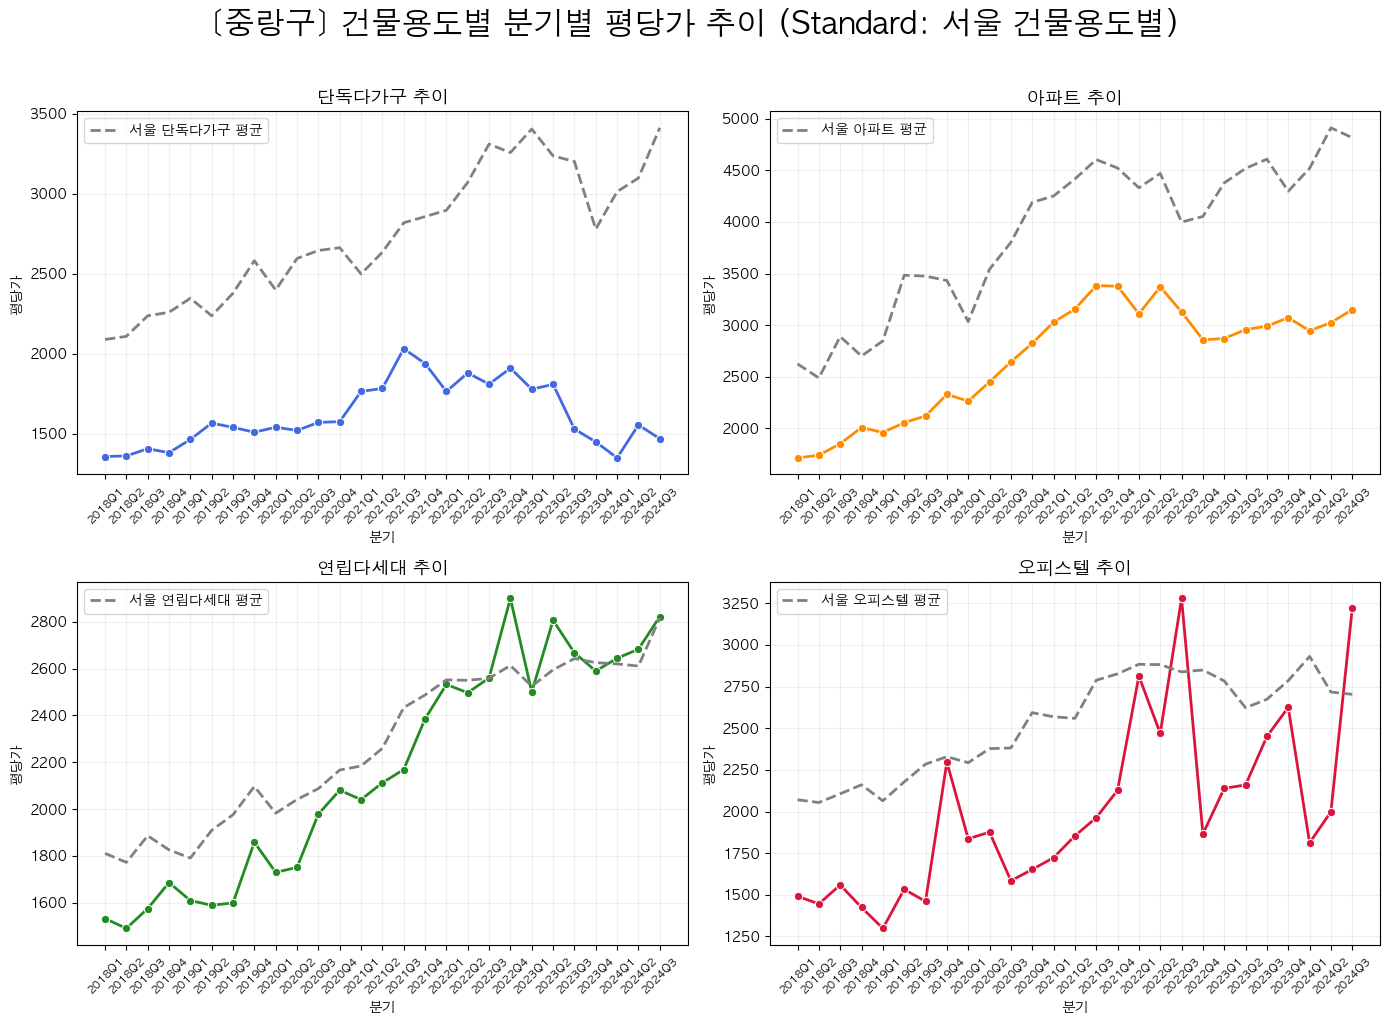

In [47]:
# 1. 자치구 데이터 필터링
jn_df = df[df['CGG_NM'] == '중랑구'].copy()

# 2. 2x2 서브플롯 생성
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten() # 2차원 배열을 1차원으로 펼쳐 반복문을 쉽게 만듦

# --- 용도별 4개 그래프 ---
usg_types = ['단독다가구', '아파트', '연립다세대', '오피스텔']
colors = ['royalblue', 'darkorange', 'forestgreen', 'crimson']

for i, usg in enumerate(usg_types):
    ax = axes[i]
    data = jn_df[jn_df['BLDG_USG'] == usg].groupby('QUARTER')['AMT_PER_PYEONG'].mean().reset_index()
    seoul_data = df[df['BLDG_USG'] == usg].groupby('QUARTER')['AMT_PER_PYEONG'].mean().reset_index()
    
    if not data.empty:
        sns.lineplot(data=data, x='QUARTER', y='AMT_PER_PYEONG', marker='o', 
                        ax=ax, color=colors[i], linewidth=2)
        sns.lineplot(data=seoul_data, x='QUARTER', y='AMT_PER_PYEONG', 
                    ax=ax, color='gray', linestyle='--', linewidth=2, label=f'서울 {usg} 평균')
        
    ax.set_title(f"{usg} 추이", fontsize=13)
    ax.set_xlabel("분기")
    ax.set_ylabel("평당가")
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.grid(True, alpha=0.2)

plt.suptitle(f"[중랑구] 건물용도별 분기별 평당가 추이 (Standard: 서울 건물용도별)", fontsize=22, y=1.02)
plt.tight_layout()
plt.show()

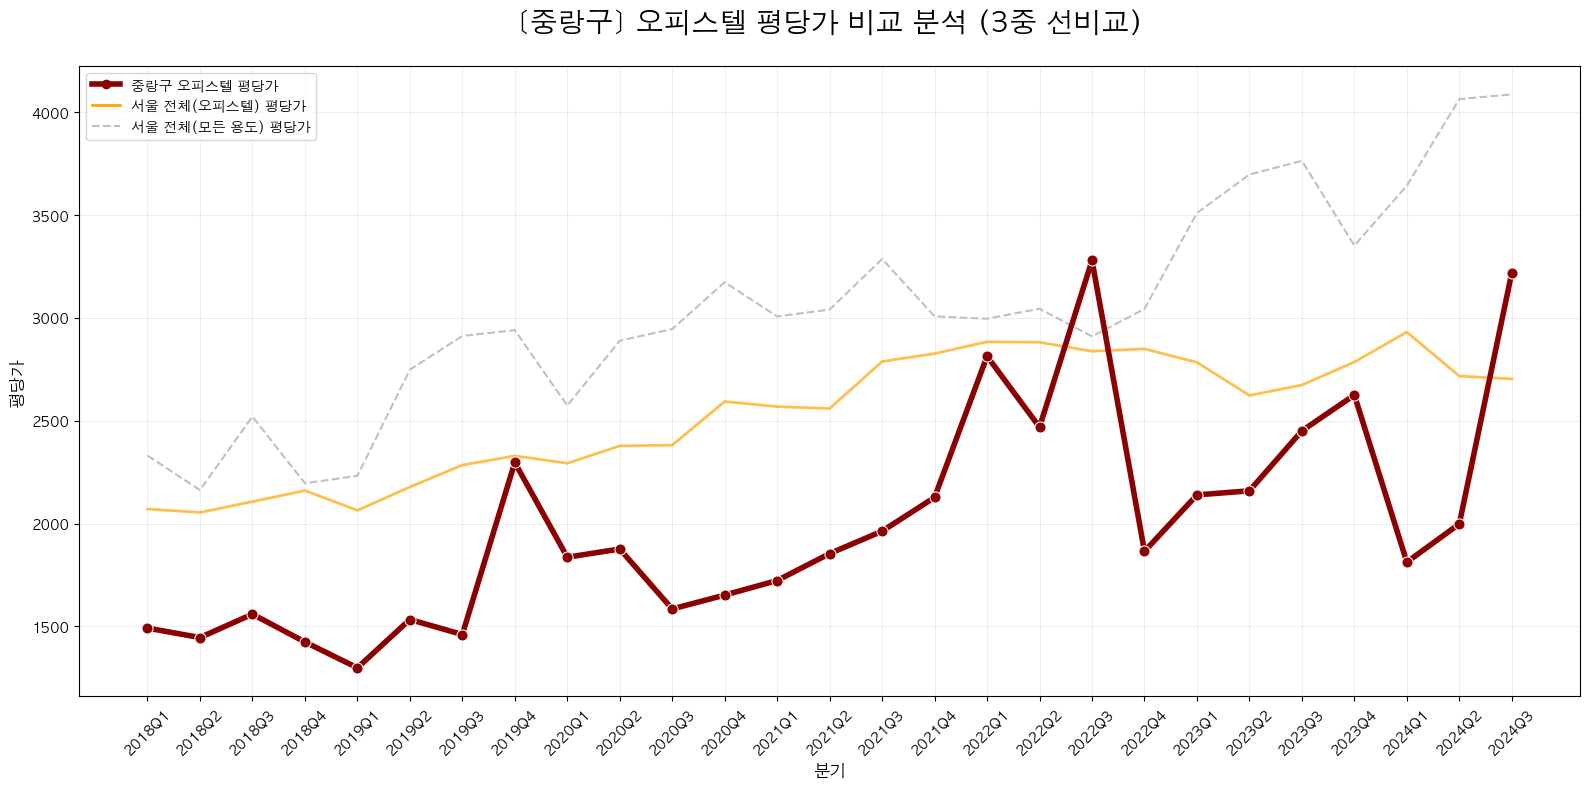

In [48]:
plt.figure(figsize=(16, 8))

# 데이터
seoul = df.groupby('QUARTER')['AMT_PER_PYEONG'].mean().reset_index()
seoul_off = df[df['BLDG_USG'] == '오피스텔'].groupby('QUARTER')['AMT_PER_PYEONG'].mean().reset_index()
jn_off = jn_df[jn_df['BLDG_USG'] == '오피스텔'].groupby('QUARTER')['AMT_PER_PYEONG'].mean().reset_index()

# 전체 서울 전체 건물 용도 평당가
sns.lineplot(data=seoul, x='QUARTER', y='AMT_PER_PYEONG',
                color='silver', linewidth=1.5, linestyle='--')
# 전체 서울 오피스텔 분기별 평당가
sns.lineplot(data=seoul_off, x='QUARTER', y='AMT_PER_PYEONG',
                color='orange', linewidth=2, alpha=0.7)

# 중랑구 오피스텔 분기별 평당가
sns.lineplot(data=jn_off, x='QUARTER', y='AMT_PER_PYEONG',
                color='darkred', linewidth=4, marker='o', markersize=8)

plt.ylabel('평당가', fontsize=12, fontweight='bold')
plt.xlabel('분기', fontsize=12, fontweight='bold')

# 마무리 및 범례 수동 통합 (범례 중복 해결 핵심)
plt.title(f"[중랑구] 오피스텔 평당가 비교 분석 (3중 선비교)", fontsize=20, fontweight='bold', pad=25)

# 수동으로 범례 항목 생성
line1 = plt.Line2D([0], [0], color='silver', linewidth=1.5, linestyle='--', label='서울 전체(모든 용도) 평당가')
line2 = plt.Line2D([0], [0], color='orange', linewidth=2, label='서울 전체(오피스텔) 평당가')
line3 = plt.Line2D([0], [0], color='darkred', linewidth=4, marker='o', label=f'중랑구 오피스텔 평당가')

# 하나의 축(ax1)에 모든 핸들을 모아서 출력
plt.legend(handles=[line3, line2, line1], loc='upper left', frameon=True, fontsize=10)

plt.grid(True, alpha=0.2)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [49]:
jn_2019q4 = jn_df.loc[((jn_df['QUARTER'] == '2019Q4') & (jn_df['BLDG_USG'] == '오피스텔')),['BLDG_NM','CTRT_YEAR','ARCH_YR','AMT_PER_PYEONG']] 
# 2019Q4 : 킴스타워 2019신축, 평당가 높음 (33%, 총 73건중)
jn_2022q1 = jn_df.loc[((jn_df['QUARTER'] == '2022Q1') & (jn_df['BLDG_USG'] == '오피스텔')),['BLDG_NM','CTRT_YEAR','ARCH_YR','AMT_PER_PYEONG']] 
# 2022Q1 : 성은오피스텔 2004년 건물, 평당가 높음 (19%, 총 64건중)
jn_2022q3 = jn_df.loc[((jn_df['QUARTER'] == '2022Q3') & (jn_df['BLDG_USG'] == '오피스텔')),['BLDG_NM','CTRT_YEAR','ARCH_YR','AMT_PER_PYEONG']] 
# 2022Q3 : 오피스텔(101-30) 2004년 건물, 평당가 높음 (39%, 총 31건중)
jn_2024q3 = jn_df.loc[((jn_df['QUARTER'] == '2024Q3') & (jn_df['BLDG_USG'] == '오피스텔')),['BLDG_NM','CTRT_YEAR','ARCH_YR','AMT_PER_PYEONG']] 
# 2024Q3 : (103-3) 2024신축, 가격대 높음 (77%, 총 73건중))

In [63]:
jn_2019q4

,BLDG_NM,CTRT_YEAR,ARCH_YR,AMT_PER_PYEONG
703513,킴스타워,2019,2019,3027.505612
703514,킴스타워,2019,2019,2995.573486
703515,킴스타워,2019,2019,2995.573486
703516,킴스타워,2019,2019,2995.573486
703517,킴스타워,2019,2019,2994.914820
...,...,...,...,...
728134,금강리빙스텔,2019,2003,1278.614627
728179,동일씨엘로,2019,2019,2851.519097
728180,동일씨엘로,2019,2019,2825.833030
728181,동일씨엘로,2019,2019,2825.833030


In [51]:
target = ['킴스타워', '성은오피스텔', '오피스텔(101-30)', '(103-3)']
target_off = jn_df[jn_df['BLDG_NM'].isin(target)].copy()

In [52]:
target_off

,Unnamed: 0.1,Unnamed: 0,CGG_CD,CGG_NM,STDG_CD,STDG_NM,BLDG_NM,CTRT_DAY,THING_AMT,ARCH_AREA,...,RGHT_SE,ARCH_YR,BLDG_USG,DCLR_SE,CTRT_YEAR,QUARTER,QUARTER_INT,CTRT_BLDG_AGE,AMT_PER_AREA,AMT_PER_PYEONG
133852,133852,168924,11260,중랑구,10100,면목동,킴스타워,2019-12-16,29900,30.61,...,NaN,2019,아파트,NaN,2019,2019Q4,12,0,976.804966,3229.121856
133860,133860,168944,11260,중랑구,10100,면목동,킴스타워,2019-12-16,31500,32.24,...,NaN,2019,아파트,NaN,2019,2019Q4,12,0,977.047146,3229.922457
133864,133864,168954,11260,중랑구,10100,면목동,킴스타워,2019-12-16,30200,30.61,...,NaN,2019,아파트,NaN,2019,2019Q4,12,0,986.605684,3261.521072
133866,133866,168958,11260,중랑구,10100,면목동,킴스타워,2019-12-16,30200,30.61,...,NaN,2019,아파트,NaN,2019,2019Q4,12,0,986.605684,3261.521072
133867,133867,168964,11260,중랑구,10100,면목동,킴스타워,2019-12-16,29900,30.04,...,NaN,2019,아파트,NaN,2019,2019Q4,12,0,995.339547,3290.393475
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
770974,770974,763338,11260,중랑구,10100,면목동,(103-3),2024-08-29,27790,25.80,...,NaN,2024,오피스텔,직거래,2024,2024Q3,8,0,1077.131783,3560.782248
770975,770975,763339,11260,중랑구,10100,면목동,(103-3),2024-08-29,29187,25.80,...,NaN,2024,오피스텔,직거래,2024,2024Q3,8,0,1131.279070,3739.782349
770976,770976,763340,11260,중랑구,10100,면목동,(103-3),2024-08-29,28359,25.80,...,NaN,2024,오피스텔,직거래,2024,2024Q3,8,0,1099.186047,3633.689233
770977,770977,763341,11260,중랑구,10100,면목동,(103-3),2024-08-29,28100,25.80,...,NaN,2024,오피스텔,직거래,2024,2024Q3,8,0,1089.147287,3600.503101


/var/folders/s9/dc7mvn1n1nl45gw342h0m_kr0000gn/T/ipykernel_24235/4081897709.py:9: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_filtered = jn_df[mask].copy()


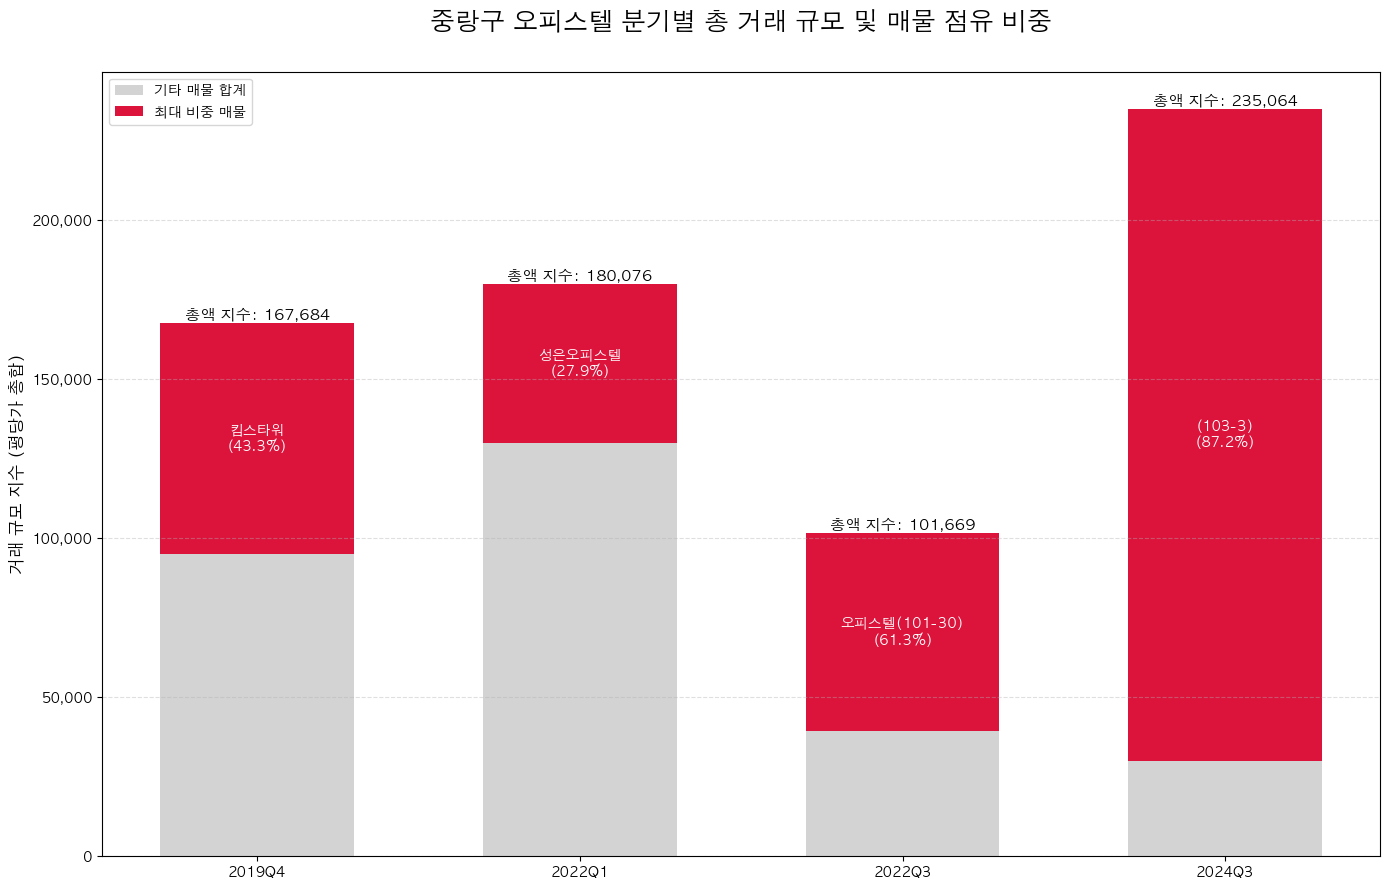

In [53]:
import matplotlib.ticker as ticker

target_quarters = ['2019Q4', '2022Q1', '2022Q3', '2024Q3']

# 해당 조건 데이터 추출 (거래금액 계산을 위해 전용면적과 평당가 활용 또는 총액 컬럼 사용)
# 가중치를 보여주기 위해 (평당가 * 건수)를 '거래 영향도(금액 규모)'로 정의

mask = (jn_df['BLDG_USG'] == '오피스텔') & (df['QUARTER'].isin(target_quarters))
df_filtered = jn_df[mask].copy()

# '거래 규모' 산출 (예: 평당가 * 1(건)의 합산)
df_filtered['transaction_volume'] = df_filtered['AMT_PER_PYEONG'] 

plot_data = []

for q in target_quarters:
    # 해당 분기
    q_data = df_filtered[df_filtered['QUARTER'] == q]

    # 모든 거래의 평당가를 합한 값 = 총 거래 규모    
    total_market_vol = q_data['transaction_volume'].sum()
    
    # 건물별 거래 규모 합계
    bldg_volumes = q_data.groupby('BLDG_NM')['transaction_volume'].sum().reset_index()
    # 분기별 거래량이 가장 많은 건물
    top_bldg = bldg_volumes.loc[bldg_volumes['transaction_volume'].idxmax()]
    
    top_name = top_bldg['BLDG_NM']
    top_vol = top_bldg['transaction_volume']
    others_vol = total_market_vol - top_vol
    share_pct = (top_vol / total_market_vol) * 100
    
    plot_data.append({
        'QUARTER': q,
        'Top_Name': top_name,
        'Top_Vol': top_vol,
        'Others_Vol': others_vol,
        'Total_Vol': total_market_vol,
        'Share_Pct': share_pct
    })

pdf = pd.DataFrame(plot_data)

# 2. 시각화
fig, ax = plt.subplots(figsize=(14, 9))

bar_width = 0.6
# 누적 막대 그래프 (기타 매물 위에 주요 매물 쌓기)
ax.bar(pdf['QUARTER'], pdf['Others_Vol'], color='lightgray', label='기타 매물 합계', width=bar_width)
ax.bar(pdf['QUARTER'], pdf['Top_Vol'], bottom=pdf['Others_Vol'], color='crimson', label='최대 비중 매물', width=bar_width)

# 3. 라벨링 및 텍스트 추가
for i, row in pdf.iterrows():
    # 총 거래 규모 표시 (막대 꼭대기)
    ax.text(i, row['Total_Vol'], f"총액 지수: {row['Total_Vol']:,.0f}", 
            ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    # 주요 매물 정보 및 비중(%) 표시
    ax.text(i, row['Others_Vol'] + (row['Top_Vol']/2), 
            f"{row['Top_Name']}\n({row['Share_Pct']:.1f}%)", 
            ha='center', va='center', color='white', fontweight='bold', fontsize=10)

# 그래프 스타일링
ax.set_title(f"중랑구 오피스텔 분기별 총 거래 규모 및 매물 점유 비중", fontsize=18, fontweight='bold', pad=30)
ax.set_ylabel("거래 규모 지수 (평당가 총합)", fontsize=12)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.legend()

plt.tight_layout()
plt.show()

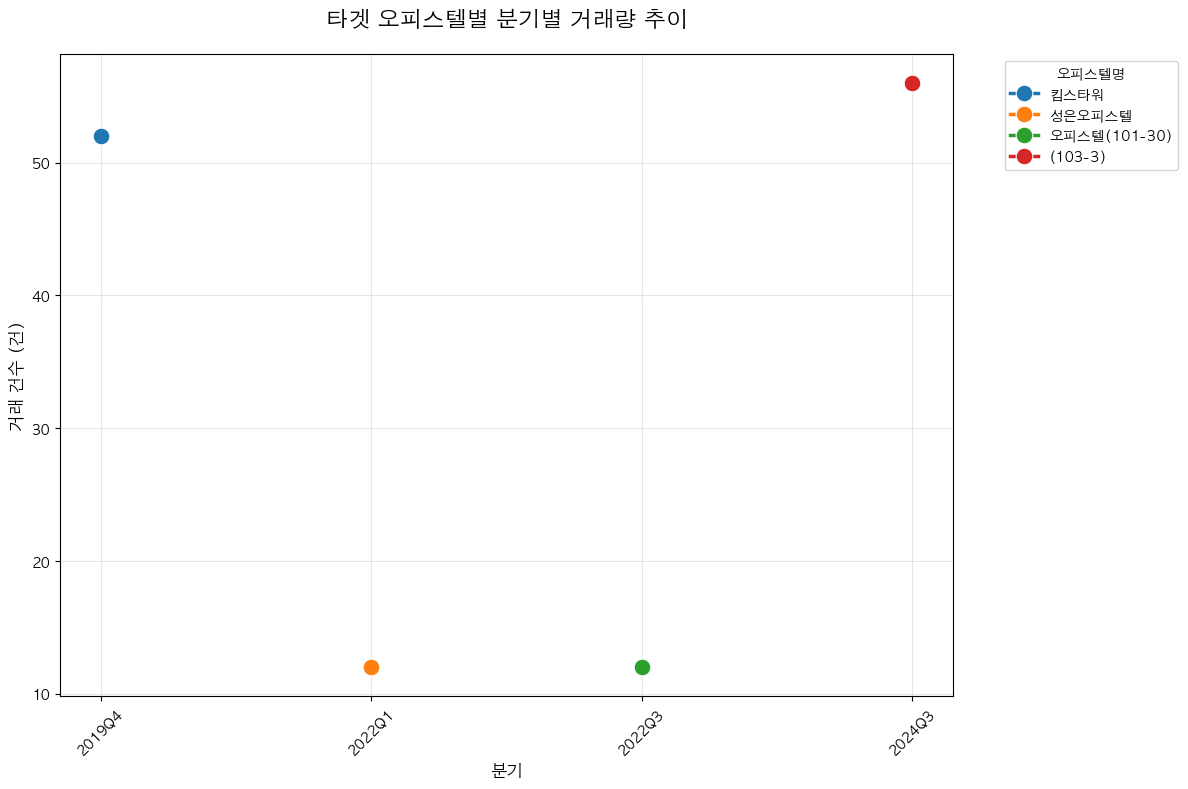

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

# 데이터 집계: 오피스텔별, 분기별 거래 건수(size) 계산
vol_stats = target_off.groupby(['QUARTER', 'BLDG_NM']).size().reset_index(name='count')

# 시각화
plt.figure(figsize=(12, 8))
sns.lineplot(data=vol_stats, x='QUARTER', y='count', hue='BLDG_NM', 
             marker='o', markersize=12, linewidth=2.5)

plt.title("타겟 오피스텔별 분기별 거래량 추이", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("분기", fontsize=12)
plt.ylabel("거래 건수 (건)", fontsize=12)
plt.xticks(rotation=45)
plt.legend(title="오피스텔명", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()